# Obróbka danych
PLIK DO TESTOWANIA KONWERSJI DANYCH

Credits:
- List muzyki pobrana z: https://www.musicgenreslist.com/
- Projekt dyplomowy wykonany razem z:
    - Katarzyna Kotus-Kozyra
    - Nora Dybowska
    - Patrycja Ślepowrońska

## To Do

- Wykresy:
    
    - Wspólne tagi - 0%?
    - Pojedyńcze litery gatunki - Global analiza
    - Nazwy funkcji od wykresów - globla analize
    - Pojedyńcze litery w tagach

- Podwójne wczytnie df
- Czy trzeba na każdą stronę wczytywać osobno?
- Tagi jako chmura, a nie pie chart

### Porównanaie z global
- Ogólna lista global
- Inne wykresy

### Shiny General

- Sprawdzić czemu są błędy dla Patrycji w porównaniu parametrów?
- Jedno wczytanie ramki dancyh na całe shiny
- Funkcja do tagów
    - podobne kolory
    - ilość tagów jako parametr
    - przerobienie funkcji - df jako wejście

- Z shiny trzeba odczytać tagi - bo domyślnie są wrzucone pewnie nie wyniki tylko wejściowe ramki danych

### Single 

- czysta ramka z opcją filtorwania

### Porównanie użytkowników

- Wykresy porównawcze?
- Tagi - podobne kolory
- Dekady - podobne kolory
- Imiona osób


### analiza Danych

- Komentarz z openAI
- Track age powinien być licznony na bieżąco - dodać funkcję do klasy i usunąć z lokalnej bazy
- Analiza które wygenerowane przez AI
- yt analyzer - problem SABR - workaround za pomocą cookies, ale trzeba spróbować to jakoś obejść
https://github.com/yt-dlp/yt-dlp/issues/12482
- Znalezienie najstarszej opcji piosenki
-  gatunek, (openAI) !!*
- update tagów w pliku lokalnym 
- zamiana csv lokalnego na db
- Odczytujemy moją ramkę df_result i ją obrabiamy

### Done

- Wykresy:
    - Single: Tempo vs ilość i popularność vs ilość
    - 2User: Tagi użytkownika
    - User_global: BPM/ normalizacja
- Czemu pokazuje thunder jako polecane - Marcin + Basia / pokaż utwór + artysta
- Potrójne wczytanie plików

## Import bibliotek

In [ ]:
#pip install requirements.txt

In [1]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

from dotenv import load_dotenv
import os

import pandas as pd
import requests
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sps

import json
from openai import OpenAI
import re

import tempfile
import librosa
import yt_dlp

from datetime import datetime
from pathlib import Path

from Plugins.Utils import create_track_artist_column

## Wczytanie danych

In [2]:
load_dotenv("log_data.env")

True

In [3]:
analyser_path = Path(os.getcwd()).resolve()

csv_filename = 'TopFresh2025'
full_path = analyser_path / 'NewData' / f"{csv_filename}.csv"

# if os.path.exists(full_path):
#     print("Plik istnieje!")
#     df_wrapped = pd.read_csv(full_path)
# else:
#     print("Plik nie istnieje w podanej lokalizacji.")


### Przygotowanie pliku

In [ ]:
from Plugins.DataProcess import WrappedDataPrepare

In [ ]:
prepare_file = WrappedDataPrepare()
df_wrapped = prepare_file.file_load(full_path)
df_wrapped = prepare_file.prepare_columns(df_wrapped)
wrapped_year = prepare_file.year_from_name(csv_filename)

## Import from local db

In [ ]:
class ImportFromLocalPlugin:
    '''
    Importujemy dane z lokalnego pliku csv do którego uprzednio zapisaliśmy wyniki z różnych api
    '''
    def __init__(self):
        pass

    def import_from_local_csv(self, df_wrapped, df_local):
        df_local = create_track_artist_column(df_local)
        df_wrapped = create_track_artist_column(df_wrapped)

        df_local = df_local.drop(columns=["Track name","Artist name","Album"])
        df_from_local = pd.merge(df_wrapped, df_local, how="left", on="Track Artist")
        df_from_local = df_from_local.drop(columns=["Track Artist"])
        
        return df_from_local

In [ ]:
import_local = ImportFromLocalPlugin()

local_path = analyser_path / 'LocalDB/LocalValues.csv'
df_local = pd.read_csv(local_path, index_col="Unnamed: 0")

df_from_local = import_local.import_from_local_csv(df_wrapped, df_local)

In [ ]:
local_path = analyser_path + "LocalDB/LocalValues.csv"
df_local = pd.read_csv(local_path, index_col="Unnamed: 0")

df_local = create_track_artist_column(df_local)
df_wrapped = create_track_artist_column(df_wrapped)

df_local = df_local.drop(columns=["Track name","Artist name","Album"])
df_from_local = pd.merge(df_wrapped, df_local, how="left", on="Track Artist")
df_from_local = df_from_local.drop(columns=["Track Artist"])

### Wyczyszczenie [ ] w tagach i gatunkach

In [ ]:
def cut_brackets(name):
    '''
    Cut first and last bracket
    '''

    if name[-1:]==']' and name[0:1]=='[':
        name_output = name[1:-1]
    else:
        name_output = name
        print("no brackets found")

    return name_output

In [ ]:
#df_local["Tags"].apply(lambda x: cut_brackets(x))
df_local["Genres"] = df_local["Genres"].apply(lambda x: cut_brackets(x))

In [ ]:
date_now = datetime.now().strftime("%Y/%m/%d")
df_local["Update_date"] = date_now

In [ ]:
df_local.to_csv(local_path)

## Wczytanie danych spotipy

In [ ]:
spotipy_key = os.getenv("SPOTIPY_KEY")
spotipy_id = os.getenv("SPOTIPY_ID")

auth_manager = SpotifyClientCredentials(client_id=spotipy_id, client_secret=spotipy_key)
sp = spotipy.Spotify(auth_manager=auth_manager)

    # def search_song(self, song_name, artist_name):
    #     q="track:"+str(song_name)+" artist:"+str(artist_name)
    #     results = self.sp.search(q=q, type='track', limit=1)
    #     if results['tracks']['items']:
    #         track = results['tracks']['items'][0]
    #         artist_id = track['artists'][0]['id']

    #         # Pobranie informacji o artyście, w tym gatunkach muzycznych
    #         artist_info = self.sp.artist(artist_id)

    #         return {
    #             'spotify_popularity': track['popularity'],
    #             'spotify_release_date': track['album']['release_date'],
    #             #'energy': features['energy']

In [ ]:
song_name = "Collect 200"
artist_name = "Collect 200"

In [ ]:
song_name = "Melodrama"
artist_name = "Anjelina Mango"

In [ ]:
q= "track:"+str(song_name)+" artist:"+str(artist_name)
results = sp.search(q=q, type='track', limit=1)

if results['tracks']['items']:
    track = results['tracks']['items'][0]
    artist_id = track['artists'][0]['id']
    artist_info = sp.artist(artist_id)
else:
    print(f"brak rezultatów dla wyszukania: {song_name} - {artist_name}, szukam samej piosenki")
    q= "track:"+str(song_name)
    results = sp.search(q=q, type='track', limit=1)
    if results['tracks']['items']:
        track = results['tracks']['items'][0]
        artist_id = track['artists'][0]['id']
        artist_info = sp.artist(artist_id)
    else:
        print(f"Brak rezultatów")


In [ ]:
# przeniesione do pluginu
from Plugins.DataLoad import SpotipyPlugin 

In [ ]:
SpotipySearch = SpotipyPlugin()

In [ ]:
song_info = SpotipySearch.search_song("Collect 200","Collect 200")

In [ ]:
SpotipySearch = SpotipyPlugin()
#SpotipySearch.__init__()
df_spotify = SpotipySearch.update_dataframe_with_spotify_info(df_wrapped, 'Track name', 'Artist name')
df_spotify = SpotipySearch.update_release_year_age(df_spotify, wrapped_year)


## Rest API Last FM

### rest API last FM
- Application name	Music style comparator
- Registered to	kotlarekm

### Funkcja do wyszukiwania

In [ ]:
# przeniesione do pluginu
from Plugins.DataLoad import LastFMPlugin 

In [ ]:
class LastFMPlugin:
    '''
    Klasa wyciągania danych z LastFM
    '''
    def __init__(self):
        self.last_fm_key = os.getenv("LAST_FM_KEY")
        self.last_fm_url = os.getenv("LAST_FM_URL")
        self.analyser_path = Path(os.getcwd()).resolve()

    def search_artist_tag(self, artist_name):
        '''
        Wyszukiwanie tagow z last fm api
        '''
        params = {
            'method': 'artist.getInfo',
            'artist': artist_name,
            'user': 'RJ',   # czemu tu jest RJ to nie wiem
            'api_key': self.last_fm_key,
            'format': 'json'
        }

        response = requests.get(self.last_fm_url, params=params)

        if response.status_code == 200:
            data = response.json()
            tags = data['artist']['tags']['tag']
            tag_list = [tag['name'] for tag in tags]
            #for tag in tags:
            #   print(f"Nazwa: {tag['name']}, URL: {tag['url']}")
        else:
            tag_list = []
            print(f"Błąd: {response.status_code}")

        return tag_list


    def update_dataframe_with_artist_tags(self, df, artist_column="Artist name"):
        '''
        Wyciągamy tagi:
        1. stwórz listę unikalnych wykonawców
        2. wyciągnij tagi z api
        3. left join do pierwotnego df
        '''

        unique_artist = df[artist_column].unique()
        df_unique = pd.DataFrame({artist_column:unique_artist})
        artists_count = unique_artist.size
        df_unique['Tags'] = None

        for index, row in df_unique.iterrows():
            print('Analiza LastFM: '+ str(index+1)+'/'+str(artists_count))
            tag_list = self.search_artist_tag(row[artist_column])
            df_unique.at[index, 'Tags'] = tag_list

        df = pd.merge(df, df_unique, on=artist_column, how="left")
        print("Data merged")

        return df
    
    def search_track_tag(self, artist_name, track_name):
        '''
        Wyszukiwanie tagow z last fm api
        '''
        params = {
            'method': 'track.getInfo',
            'artist' : artist_name,
            'track': track_name,
            #'user': 'RJ',   # czemu tu jest RJ to nie wiem
            'api_key': self.last_fm_key,
            'format': 'json'
        }

        response = requests.get(self.last_fm_url, params=params)

        if response.status_code == 200:
            try:
                data = response.json()
                tags = data['track']['toptags']['tag']
                tag_list = [tag['name'] for tag in tags]
            except:
                tag_list = []
                print(f"Błąd: {response.status_code}")                  

        else:
            tag_list = []
            print(f"Błąd: {response.status_code}")

        return tag_list

    def search_artist_tag(self, artist_name):
        '''
        Wyszukiwanie tagow z last fm api z artystow
        '''
        params = {
            'method': 'artist.getInfo',
            'artist' : artist_name,
            #'user': 'RJ',   # czemu tu jest RJ to nie wiem
            'api_key': self.last_fm_key,
            'format': 'json'
        }

        response = requests.get(self.last_fm_url, params=params)

        if response.status_code == 200:
            try:
                data = response.json()
                tags = data['artist']['tags']['tag']
                tag_list = [tag['name'] for tag in tags]
            except:
                tag_list = []
                print(f"Błąd: {response.status_code}")                  

        else:
            tag_list = []
            print(f"Błąd: {response.status_code}")

        return tag_list

    def update_dataframe_with_track_tags(self, df, artist_column='Artist name', track_column='Track name'):
        '''
        Wyciągamy tagi z piosenek
        '''
        track_count = df[track_column].size
        df['Tags'] = None

        for index, row in df.iterrows():
            print('Analiza LastFM: '+ str(index+1)+'/'+str(track_count))
            tag_list = self.search_track_tag(track_name= row[track_column] ,artist_name=row[artist_column])
            if len(tag_list) == 0:
                print("Brak tagów na ścieżce, szukam w artyście")
                tag_list = self.search_artist_tag(artist_name=row[artist_column])
            df.at[index, 'Tags'] = tag_list

        return df

    def genres_from_tags(self, df):
        ''' 
        Wyciągamy gatunki z tagów
        '''
        full_path = self.analyser_path / "LocalDB" / "Genres.csv" 
        df_genres = pd.read_csv(full_path)
        df["Genres"] = None
        print(type(df["Tags"][0]))
        df["Genres"] = df["Tags"].apply(lambda x: [element for element in x if element.lower() in map(str.lower, df_genres["Genres"].tolist())])

        return df   

In [ ]:
artist_name = 'The Avener'
track_name = 'Quando Quando'

# artist_name = 'Imagine Dragons'
# track_name = 'Thunder'

In [ ]:
last_fm_url = os.getenv("LAST_FM_URL")
last_fm_key = os.getenv("LAST_FM_KEY")

params = {
    'method': 'track.getInfo',
    'artist' : artist_name,
    'track': track_name,
    'user': 'RJ',   # czemu tu jest RJ to nie wiem
    'api_key': last_fm_key,
    'format': 'json'
}

response = requests.get(last_fm_url, params=params)

if response.status_code == 200:
    try:
        data = response.json()
        print(data)
        tags = data['track']['toptags']['tag']
        tag_list = [tag['name'] for tag in tags]
        print(len(tag_list))
    except:
        tag_list = []
        print(f"Błąd: {response.status_code}")                  

else:
    tag_list = []
    print(f"Błąd: {response.status_code}")

print(tag_list)

In [ ]:
last_fm_url = os.getenv("LAST_FM_URL")
last_fm_key = os.getenv("LAST_FM_KEY")

params = {
    'method': 'artist.getInfo',
    'artist' : artist_name,
    'track': track_name,
    #'user': 'RJ',   # czemu tu jest RJ to nie wiem
    'api_key': last_fm_key,
    'format': 'json'
}

response = requests.get(last_fm_url, params=params)

if response.status_code == 200:
    try:
        data = response.json()
        print(data)
        tags = data['artist']['tags']['tag']
        tag_list = [tag['name'] for tag in tags]
    except:
        tag_list = []
        print(f"Błąd: {response.status_code}")                  

else:
    tag_list = []
    print(f"Błąd: {response.status_code}")

print(tag_list)

In [ ]:
#wyciągnia
last_fm_search = LastFMPlugin()
df_lastfm = last_fm_search.update_dataframe_with_track_tags(df_spotify, 'Artist name', 'Track name')
df_lastfm = last_fm_search.genres_from_tags(df_lastfm)

Po cały procesie mamy: ['funk', 'soul', 'Disco', '70s', '80s'] i <class 'list'>

## Youtube API

In [ ]:
class YouTubeAnalyzerPlugin:
    def __init__(self):
        pass

    def enrich(self, query):
        title = query.get("title")
        artist = query.get("artist")
        if not title or not artist:
            return {"youtube_audio": []}

        search_query = f"ytsearch1:{artist} - {title}"
        results = []

        try:
            with tempfile.TemporaryDirectory() as tmpdir:
                output_path = os.path.join(tmpdir, "audio.wav")
                print(f"[YouTubeAudio] Searching and downloading: {search_query}")

                ydl_opts = {
                    'format': 'bestaudio/best',
                    'outtmpl': os.path.join(tmpdir, 'audio.%(ext)s'),
                    'proxy': None,
                    'postprocessors': [{
                        'key': 'FFmpegExtractAudio',
                        'preferredcodec': 'wav',
                        'preferredquality': '192',
                    }],
                    'quiet': True,
                    'default_search': 'ytsearch',
                    'noplaylist': True,
                    'extract_flat': False,
                    'skip_download': False,
                }

                with yt_dlp.YoutubeDL(ydl_opts) as ydl:
                    info_dict = ydl.extract_info(search_query, download=True)
                    video_title = info_dict['title']
                    video_url = f"https://www.youtube.com/watch?v={info_dict['id']}"

                print(f"[YouTubeAudio] Downloaded: {video_title} ({video_url})")

                y, sr = librosa.load(output_path, sr=None)
                print(f"[YouTubeAudio] Loaded audio: {len(y)} samples @ {sr} Hz")

                # --- ANALIZA ---
                try:
                    bpm = float(round(librosa.feature.tempo(y=y, sr=sr)[0]))
                except Exception as e:
                    print(f"[YouTubeAudio] bpm error: {e}")
                    bpm = None

                try:
                    energy = float(np.mean(librosa.feature.rms(y=y)))
                except Exception as e:
                    print(f"[YouTubeAudio] energy error: {e}")
                    energy = None

                try:
                    danceability = float(np.mean(librosa.onset.onset_strength(y=y, sr=sr)))
                except Exception as e:
                    print(f"[YouTubeAudio] danceability error: {e}")
                    danceability = None

                try:
                    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
                    spectral_centroid_mean = float(np.mean(spectral_centroid))
                except Exception as e:
                    print(f"[YouTubeAudio] spectral centroid error: {e}")
                    spectral_centroid_mean = None

                try:
                    mood = self._estimate_mood(bpm, energy, danceability, spectral_centroid_mean)
                except Exception as e:
                    print(f"[YouTubeAudio] mood estimation error: {e}")
                    mood = "unknown"

                results.append({
                    "title": video_title,
                    "youtube_url": video_url,
                    "bpm": round(bpm) if bpm is not None else None,
                    "energy": round(energy, 4) if energy is not None else None,
                    "danceability": round(danceability, 4) if danceability is not None else None,
                    "mood": mood
                })

        except Exception as e:
            print(f"[YouTubeAudio] FATAL ERROR: {e}")
            results.append({"error": str(e)})

        return {"youtube_audio": results}

    def _estimate_mood(self, bpm, energy, danceability, brightness):
        if None in (bpm, energy, danceability, brightness):
            return "unknown"
        if bpm > 120 and energy > 0.05 and danceability > 0.05:
            return "energetic"
        elif brightness < 2000 and danceability < 0.03:
            return "melancholic"
        elif brightness > 3000:
            return "bright"
        else:
            return "neutral"
        
    def update_dataframe(self, df, track_name_column, artist_column):
        '''
        Update with estimated values 
        '''
        df['bpm'] = None
        df['energy'] = None
        df['danceability'] = None
        df['mood'] = None
        unique_tracks = df[track_name_column].size

        for index, row in df.iterrows():
            print('Progress: '+ str(index+1)+'/'+str(unique_tracks) ) 
            query = {
                "title": row[track_name_column],
                "artist": row[artist_column],
                "limit": 1
            }    
            song_analyse = self.enrich(query=query)
            song_info = song_analyse['youtube_audio'][0]
            df.at[index, 'bpm'] = song_info['bpm']
            df.at[index, 'energy'] = song_info['energy']
            df.at[index, 'danceability'] = song_info['danceability']
            df.at[index, 'mood'] = song_info['mood']


        return df

In [ ]:
from Plugins.DataLoad import YouTubeAnalyzerPlugin

In [ ]:
youtube_search = YouTubeAnalyzerPlugin()
df_youtube = youtube_search.update_dataframe(df_lastfm, 'Track name', 'Artist name')

## Open AI API

In [ ]:
### PLUGIN NORY
class OpenAIPlugin:
    def __init__(self):
        self.api_key = os.getenv("OPENAI_API_KEY")
        self.model = os.getenv("OPENAI_MODEL", "gpt-4")
        self.client = OpenAI(api_key=self.api_key)

    def enrich(self, query):
        title = query.get("title")
        artist = query.get("artist")
        limit = int(query.get("limit", 1))

        if not self.api_key or not title or not artist:
            return {"openai": []}

        results = []

        try:
            for _ in range(limit):
                prompt = (
                    f"Track title: {title}\n"
                    f"Artist: {artist}\n\n"
                    "Please provide a detailed musical analysis of this song in JSON format with the following fields:\n"
                    "- bpm (number)\n"
                    "- energy (number from 0 to 1)\n"
                    "- danceability (number from 0 to 1)\n"
                    "- mood (string, e.g. \"happy\", \"melancholic\", etc.)\n"
                    "- genre (string)\n"
                    "Respond only with a valid JSON object and nothing else."
                )

                response = self.client.chat.completions.create(
                    model=self.model,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.7,
                    max_tokens=700
                )

                reply = response.choices[0].message.content.strip()

                # 🧹 Oczyszczanie markdown, prefiksów, opakowań
                cleaned = self._extract_json(reply)

                try:
                    parsed = json.loads(cleaned)
                    validated = self._validate_response(parsed)
                    results.append(validated)
                except json.JSONDecodeError:
                    results.append({
                        "error": "Invalid JSON from model",
                        "raw_response": reply
                    })

        except Exception as e:
            results.append({"error": str(e)})

        return {"openai": results}

    def _extract_json(self, text):
        """
        Usuwa markdownowe opakowania i wyodrębnia czysty JSON z tekstu.
        """
        # Szukaj pierwszego bloku JSON w stylu {...}
        match = re.search(r"{.*?}", text, re.DOTALL)
        return match.group(0) if match else text.strip()

    def _validate_response(self, data):
        """
        Waliduje i normalizuje odpowiedź JSON od modelu.
        """
        defaults = {
            "bpm": None,
            "energy": None,
            "danceability": None,
            "mood": None,
            "genre": None
        }

        result = {}
        for key in defaults:
            value = data.get(key, defaults[key])

            # Typowe konwersje
            if key in ["bpm", "time_signature"]:
                try:
                    value = int(value)
                except (ValueError, TypeError):
                    value = None
            elif key in ["energy", "danceability", "acousticness", "instrumentalness"]:
                try:
                    value = float(value)
                    if not (0 <= value <= 1):
                        value = None
                except (ValueError, TypeError):
                    value = None
            elif isinstance(value, str):
                value = value.strip()

            result[key] = value

        return result

In [ ]:
openAi_query = OpenAIPlugin()
query = {
        "title": df_lastfm["Track name"][0],
        "artist": df_lastfm["Artist name"][0],
        "limit": 1
    }
openAi_result = openAi_query.enrich(query=query)
print(openAi_result)

In [ ]:
### PLUGIN NORY - zmodyfikowany do 10 odpowiedzi
class OpenAIPlugin:
    def __init__(self):
        self.api_key = os.getenv("OPENAI_API_KEY")
        self.model = os.getenv("OPENAI_MODEL", "gpt-4.1")
        self.client = OpenAI(api_key=self.api_key)

    def batch_enrich(self, df, batch_size=8, artist_column_name="Artist name", track_column_name="Track name"):
        '''
        Wykonuje serię zapytań do OpenAI
        '''
        batch_result = None
        df['bpm'] = None
        df['energy'] = None
        df['danceability'] = None
        df['mood'] = None
        df['Genre'] = None

        df= create_track_artist_column(df, artist_column_name=artist_column_name, track_column_name=track_column_name)

        for i in range(0, len(df), batch_size):
            print(f"Przetwarzanie batchu {i//batch_size + 1}:")
            batch = df.iloc[i:i+batch_size]  # Pobieranie fragmentu DataFrame
            print(batch)
            #batch_result = self.update_dataframe_openAI(batch, artist_column_name=artist_column_name, track_column_name=track_column_name)
            #df.at[i:i+batch_size,:] = batch_result.at[0:batch_size,:]
            batch = self.enrich_few(batch, artist_column_name=artist_column_name, track_column_name=track_column_name)

        return batch_result


    def update_dataframe_openAI(self, df, artist_column_name="Artist name", track_column_name="Track name"):
        '''
        Wykonuje zapytanie do OpenAI i aktualizuje wczytany df
        '''    
        df_result = self.enrich_few(df=df, artist_column_name=artist_column_name, track_column_name=track_column_name)
        df_result = (pd.merge(df, df_result, left_index=True, right_index=True) #on='Track Artist')
            .drop(columns=['Genres','track_title','artist_name'])#,'Track Artist'])
            .rename(columns={'genre':'Genres'})
        )

        return df_result

    def create_track_artist_column(self, df, artist_column_name="Artist name", track_column_name="Track name"):
        '''
        łączy kolumnę track i artist w jedną
        '''
        df.loc[:,"Track Artist"] = df.loc[:,track_column_name] +" "+ df.loc[:,artist_column_name]
        df = df.assign(Track_Artist=df[track_column_name] + " " + df[artist_column_name])

        return df

    def enrich_few(self, df, artist_column_name="Artist name", track_column_name = "Track name"):
        '''
        otrzymuje odpowiedź dla kilku piosenek z wskazanego dataframe
        '''
        if not self.api_key: #or not title or not artist:
            return {"openai": []}

        limit = 1
        results = []
        prompt = ""

        try:
            for i, row in df.iterrows():
                artist = row[artist_column_name]
                track = row[track_column_name]
                prompt = prompt + f"Track title {i}: {track}\n"
                prompt = prompt + f"Artist name {i}: {artist}\n"
                
            for _ in range(limit):
                prompt = prompt + (
                    "Please provide a detailed musical analysis of those songs in JSON format with the following fields:\n"
                    "- bpm (number)\n"
                    "- energy (number from 0 to 1)\n"
                    "- danceability (number from 0 to 1)\n"
                    "- mood (string, e.g. \"happy\", \"melancholic\", etc.)\n"
                    "- genre (string)\n"
                    "Respond only with a valid JSON object and nothing else."
                )

                response = self.client.chat.completions.create(
                    model=self.model,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.7,
                    max_tokens=1000
                )

                reply = response.choices[0].message.content.strip()
                #print(reply)
                # 🧹 Oczyszczanie markdown, prefiksów, opakowań
                cleaned = self._extract_json(reply)
                results=  cleaned

        except Exception as e:
            results.append({"error": str(e)})

        return results

    def _extract_json(self, text):
        """
        Usuwa markdownowe opakowania i wyodrębnia czysty JSON z tekstu.
        """
        start = text.find("[")
        end = text.rfind("]") + 1
        if start == -1 or end == 0:
            raise ValueError("Nie znaleziono poprawnego JSON-a w odpowiedzi!")
        
        json_text = text[text.find("["):(text.rfind("]")+1)]
        json_data = json.loads(json_text)
        df = pd.DataFrame(json_data)
        print(type(df))
        print(df)
        return df


In [ ]:
df_ten = df_lastfm.head(18)
#df_ten = df_lastfm[0:8]

In [ ]:
openAi_query = OpenAIPlugin()
df_openai = openAi_query.batch_enrich(df=df_lastfm, artist_column_name="Artist name", track_column_name="Track name", batch_size=8)
#df_openai = openAi_query.update_dataframe_openAI(df=df_ten, artist_column_name="Artist name", track_column_name="Track name")
#df_openai = openAi_query.enrich_few(df=df_ten, artist_column_name="Artist name", track_column_name="Track name")
print(type(df_openai))

In [ ]:
df_openai = openAi_result
df_openai2 = (pd.merge(df_ten, df_openai, left_index=True, right_index=True)
    .drop(columns=['Genres','track_title','artist_name'])
    .rename(columns={'genre':'Genres'})
)


In [ ]:
openAi_query = OpenAIPlugin()
df = df_lastfm
df['bpm'] = None
df['energy'] = None
df['danceability'] = None
df['mood'] = None
df['Genre'] = None
df= openAi_query.create_track_artist_column(df, artist_column_name="Artist name", track_column_name="Track name")


In [ ]:
batch = df.iloc[16:24]
batch_result = openAi_query.enrich_few(batch, artist_column_name="Artist name", track_column_name="Track name")




In [ ]:
df_result = batch_result

In [ ]:
df_result = pd.concat([df_result, batch_result], ignore_index=True)

In [ ]:
openAi_query = OpenAIPlugin()
df = df_lastfm.head(8)
df_result = openAi_query.enrich_few(df,artist_column_name="Artist name", track_column_name = "Track name")

df_merge = (pd.merge(df, df_result, left_index=True, right_index=True) #on='Track Artist')
            .drop(columns=['Genres','track_title','artist_name'])#,'Track Artist'])
            .rename(columns={'genre':'Genres'})
        )

In [ ]:
openAi_query = OpenAIPlugin()
df = df_lastfm.head(8)
batch_size = 8
for i in range(0, len(df), batch_size):
            print(f"Przetwarzanie batchu {i//batch_size + 1}:")
            batch = df.iloc[i:i+batch_size]  # Pobieranie fragmentu DataFrame
            batch_result = openAi_query.update_dataframe_openAI(batch, artist_column_name="Artist name", track_column_name="Track name")
            df.iloc[i:i+batch_size] = batch_result

In [ ]:
# test.find("{")
# json_text = test[test.find("["):(test.rfind("]")+1)]
# #print(json_text)
# json_data = json.loads(json_text)
# df = pd.DataFrame(json_data)

## Obróbka danych

In [ ]:
# #df_analysis = df_lastfm
df_analysis = df_youtube

# # jeżeli mamy już dużo obrobione i wciągamy z pliku Output
# csv_filename = 'WrappedNora2024'
# full_path = analyser_path + "DataOutput\\" + csv_filename +".csv" 

# if os.path.exists(full_path):
#     print("Plik istnieje!")
#     df_lastfm = pd.read_csv(full_path)
# else:
#     print("Plik nie istnieje w podanej lokalizacji.")

In [ ]:
from Plugins.DataSummary import WrappedSummaryPlugin

In [ ]:
SpotifySummary = WrappedSummaryPlugin()
df_results = SpotifySummary.full_analysis(df_analysis)

## Porównanie dwóch playlist
### Wyciąganie wspólnych tagów

In [ ]:
analyser_path = Path(os.getcwd()).resolve()

csv_filename = 'WrappedMarcin2024'
full_path = analyser_path / "DataOutput" / f"{csv_filename}.csv"

df_base = pd.read_csv(full_path, index_col="Unnamed: 0")

csv_filename = 'WrappedKamil2024'
full_path = analyser_path / "DataOutput" / f"{csv_filename}.csv"

df_compare = pd.read_csv(full_path, index_col="Unnamed: 0")


In [ ]:
def tag_list(df):
    '''
    Wyciągamy listę tagów danego df
    '''
    all_tags = []
    for tags_list in df['Tags']:
        if isinstance(tags_list, str) and pd.notna(tags_list) and tags_list.strip():
            tags = tags_list.strip("[]")
            tags = tags.split(',')
            all_tags.extend([tag.strip() for tag in tags if tag.strip()])
    tag_top_separate = pd.Series(all_tags).value_counts()
    df_tags = tag_top_separate.reset_index()
    df_tags.columns = ['Tag','Count']
    #tag_top_separate.head(10)
    #df_results.at[0,"Top tags"] = ", ".join(Tag_top_separate.head(10).keys().to_list())

    return df_tags
        

In [ ]:
df_tags_base = tag_list(df_base)
df_tags_compare = tag_list(df_compare)

#df_tags_base = pd.Series(top_tags_base, name="count")


In [ ]:
df_joint_tags = pd.merge(df_tags_base, df_tags_compare,
                      how='inner', on='Tag')

df_joint_tags = df_joint_tags.assign(Common=lambda df: df.apply(lambda row: min(row['Count_x'], row['Count_y']), axis=1))
df_joint_tags = df_joint_tags.sort_values('Common', ascending=False).drop(columns=['Count_x','Count_y'])

In [ ]:
#print(df_joint_tags)
def sum_common_tag(df, df_joint_tags):
    '''
    Sumuje wspólne tagi w utworach
    '''        
    df['Common Tag Sum'] = None
    # df['Spotify Release Date'] = None
    # unique_tracks = df[track_name_column].size

    for index, row in df.iterrows():
        tags_list = row['Tags']
        total = 0

        if isinstance(tags_list, str) and pd.notna(tags_list) and tags_list.strip():
            tags = tags_list.strip("[]").split(',')

            for tag in tags:
                tag = tag.strip().strip("'\"") 
                try:
                    value = df_joint_tags.query(f"Tag == \"'{tag}'\"")['Common'].values[0]
                    total = total + value
                except:
                    value = 0       
        df.at[index, 'Common Tag Sum'] = total
    
    df = df.sort_values('Common Tag Sum', ascending=False)
    return df



In [ ]:
df_base = sum_common_tag(df_base, df_joint_tags)
df_compare = sum_common_tag(df_compare, df_joint_tags)

In [ ]:
df_base = create_track_artist_column(df_base)
df_compare = create_track_artist_column(df_compare)


In [ ]:
# Zakładamy, że masz dwa DataFrame’y: df_base i df_compare

# Usuń z df_base artystów, którzy są w df_compare
df_base_filtered = df_base[~df_base['Track Artist'].isin(df_compare['Track Artist'])].head(10)

# Usuń z df_compare artystów, którzy są w df_base
df_compare_filtered = df_compare[~df_compare['Track Artist'].isin(df_base['Track Artist'])].head(10)


In [ ]:
class RecommendationPlugin:
    '''
    Klasa do rekomendacji pioseneke pomiędzy dwoma ramkami danych
    '''
    def __init__(self):
        pass

    def tag_list(self, df):
        '''
        Wyciągamy listę tagów danego df
        '''
        all_tags = []
        for tags_list in df['Tags']:
            if isinstance(tags_list, str) and pd.notna(tags_list) and tags_list.strip():
                tags = tags_list.strip("[]")
                tags = tags.split(',')
                all_tags.extend([tag.strip() for tag in tags if tag.strip()])
        tag_top_separate = pd.Series(all_tags).value_counts()
        df_tags = tag_top_separate.reset_index()
        df_tags.columns = ['Tag','Count']
        #tag_top_separate.head(10)
        #df_results.at[0,"Top tags"] = ", ".join(Tag_top_separate.head(10).keys().to_list())

        return df_tags
    
    def joint_tag_list(self, df_base, df_compare):
        '''
        Wycigąmy wspólną listę tagów dla dwóch ramek danych
        '''
        df_tags_base = self.tag_list(df_base)
        df_tags_compare = self.tag_list(df_compare)

        df_joint_tags = pd.merge(df_tags_base, df_tags_compare,
                      how='inner', on='Tag')
        df_joint_tags = df_joint_tags.assign(Common=lambda df: df.apply(lambda row: min(row['Count_x'], row['Count_y']), axis=1))
        df_joint_tags = df_joint_tags.sort_values('Common', ascending=False).drop(columns=['Count_x','Count_y'])

        return df_joint_tags
    
    def sum_common_tag(self, df, df_joint_tags):
        '''
        Sumuje wspólne tagi w utworach
        '''        
        df['Common Tag Sum'] = None
        # df['Spotify Release Date'] = None
        # unique_tracks = df[track_name_column].size

        for index, row in df.iterrows():
            tags_list = row['Tags']
            total = 0

            if isinstance(tags_list, str) and pd.notna(tags_list) and tags_list.strip():
                tags = tags_list.strip("[]").split(',')

                for tag in tags:
                    tag = tag.strip().strip("'\"") 
                    try:
                        value = df_joint_tags.query(f"Tag == \"'{tag}'\"")['Common'].values[0]
                        total = total + value
                    except:
                        value = 0       
            df.at[index, 'Common Tag Sum'] = total
        
        df = df.sort_values('Common Tag Sum', ascending=False)
        return df

    def show_recommendation(self, df_base, df_compare, numer_of_recommended=10):
        '''
        Pokazuje rekomendacje między dwoma ramkami danych
        '''
        df_joint_tags = self.joint_tag_list(df_base=df_base, df_compare=df_compare)
        
        df_base = self.sum_common_tag(df_base, df_joint_tags)
        df_compare = self.sum_common_tag(df_compare, df_joint_tags)

        df_base = create_track_artist_column(df_base)
        df_compare = create_track_artist_column(df_compare)

        # Usuń z df_base artystów, którzy są w df_compare
        df_base_recommended = df_base[~df_base['Track Artist'].isin(df_compare['Track Artist'])].head(10)
        # Usuń z df_compare artystów, którzy są w df_base
        df_compare_recommended = df_compare[~df_compare['Track Artist'].isin(df_base['Track Artist'])].head(10)

        return df_base_recommended, df_compare_recommended

In [ ]:
from Plugins.DataSummary import RecommendationPlugin

In [ ]:
analyser_path = Path(os.getcwd()).resolve()

csv_filename = 'WrappedMarcin2024'
full_path = analyser_path / "DataOutput" / f"{csv_filename}.csv"

df_base = pd.read_csv(full_path, index_col="Unnamed: 0")

csv_filename = 'WrappedBasia2024'
full_path = analyser_path / "DataOutput" / f"{csv_filename}.csv"

df_compare = pd.read_csv(full_path, index_col="Unnamed: 0")

In [ ]:
Recommendation = RecommendationPlugin()

df_base_recommended, df_compare_recommended = Recommendation.show_recommendation(df_base, df_compare,10)

In [ ]:
print(df_compare_recommended)

### Write Output

In [ ]:
df_analysis.to_csv(analyser_path+"DataOutput\\" + csv_filename + ".csv")
df_results.to_csv(analyser_path+"DataOutput\\" + csv_filename+"result.csv")

# Obróbka pliku - najpierw czytaj lokalne
To czego nie ma wyciągnij z sieci

In [ ]:
# Library import

from dotenv import load_dotenv
import os
from datetime import datetime
import pandas as pd

from pathlib import Path

load_dotenv("log_data.env")

# Plugin import

from Plugins.DataLoad import SpotipyPlugin
from Plugins.DataLoad import LastFMPlugin
from Plugins.DataLoad import YouTubeAnalyzerPlugin
from Plugins.DataLoad import ImportFromLocalPlugin
from Plugins.DataProcess import WrappedDataPrepare
from Plugins.DataSummary import WrappedSummaryPlugin


In [ ]:
# Wprowadzenie danych wejściowych

analyser_path = Path(os.getcwd()).resolve()
data_dir = analyser_path / "NewData" 

file_list = os.listdir(data_dir)
file = file_list[0]
#for file in file_list:
    

In [ ]:
prepare_file = WrappedDataPrepare()
full_path = data_dir / file
print("Obróbka pliku: "+str(full_path))

df_wrapped = prepare_file.file_load(full_path)
df_wrapped = prepare_file.prepare_columns(df_wrapped)
wrapped_year = prepare_file.year_from_name(file)


In [ ]:
import_local = ImportFromLocalPlugin()
local_path = analyser_path / 'LocalDB/LocalValues.csv'
df_local = pd.read_csv(local_path, index_col="Unnamed: 0")
df_wrapped = import_local.import_from_local_csv(df_wrapped, df_local)

## Podział na dwie ramki danych

In [ ]:
df_from_local = df_wrapped[~df_wrapped["Update_date"].isna()].copy()
df_from_api = df_wrapped[df_wrapped["Update_date"].isna()].copy()

## Poprawa tagów

In [ ]:
analyser_path = Path(os.getcwd()).resolve()
data_dir = os.path.join(analyser_path, "Data")

prepare_file = WrappedDataPrepare()
full_path = os.path.join(data_dir, "WrappedMarcin2025" + ".csv")
df_wrapped = prepare_file.file_load(full_path)
df_wrapped = prepare_file.prepare_columns(df_wrapped)

In [ ]:


local_path = os.path.join(analyser_path, "LocalDB", "LocalValues.csv")
df_local = pd.read_csv(local_path, index_col="Unnamed: 0")

import_local = ImportFromLocalPlugin()
df = import_local.import_from_local_csv(df_wrapped, df_local)

df = df.dropna(subset=['Spotify Release Year'])
df['Decade'] = (df['Spotify Release Year'] // 10 * 10).astype(int).astype(str) + "s"

decade_counts = df['Decade'].value_counts(normalize=True) * 100
decade_df = decade_counts.reset_index()
decade_df.columns = ['Decade', 'Percentage']
decade_df = decade_df.sort_values("Decade")

### Wyszukanie wyników dla tych z poza bazy

In [ ]:
df_from_api['Spotify Release Year'] = (
    df_from_api['Spotify Release Date']
    .str[:4]
    .where(df_from_api['Spotify Release Date'].notna())
    .astype(float)
)

In [ ]:
SpotipySearch = SpotipyPlugin()
df_spotify = SpotipySearch.update_dataframe_with_spotify_info(df=df_from_api, track_name_column='Track name', artist_name_column='Artist name')
df_spotify = SpotipySearch.update_release_year_age(df_spotify, wrapped_year)


In [ ]:
last_fm_search = LastFMPlugin()
df_lastfm = last_fm_search.update_dataframe_with_track_tags(df=df_spotify,track_column= 'Track name', artist_column= 'Artist name')
df_lastfm = last_fm_search.genres_from_tags(df_lastfm)


In [ ]:
youtube_search = YouTubeAnalyzerPlugin()
df_youtube = youtube_search.update_dataframe(df_lastfm, 'Track name', 'Artist name')


In [ ]:
def cut_brackets(name):
    '''
    Cut first and last bracket
    '''

    if name[-1:]==']' and name[0:1]=='[':
        name_output = name[1:-1]
    else:
        name_output = name
        print("no brackets found")

    return name_output

In [ ]:
df_from_api["Genres"] = df_from_api["Genres"].apply(lambda x: str(x))
df_from_api["Tags"] = df_from_api["Tags"].apply(lambda x: str(x))

df_from_api["Genres"] = df_from_api["Genres"].apply(lambda x: cut_brackets(x))
df_from_api["Tags"] = df_from_api["Tags"].apply(lambda x: cut_brackets(x))

### Data aktualizacji

In [ ]:
date_now = datetime.now().strftime("%Y/%m/%d")
df_from_api["Update_date"] = date_now

### połączenie dwóch ramek - z bazy lokalnej i api

In [ ]:
df_combined = pd.concat([df_from_local,df_from_api]).sort_index()

## Aktualizacja lokalnego csv

In [ ]:
df_local = pd.concat([df_local,df_from_api], ignore_index=True)

In [ ]:
local_path = analyser_path / "LocalDB/LocalValues.csv"
df_local.to_csv(local_path)

In [ ]:
SpotifySummary = WrappedSummaryPlugin()
df_results = SpotifySummary.full_analysis(df_combined)

wrapped_name = file.split(".")[0]

df_youtube.to_csv(analyser_path / "DataOutput" / (wrapped_name + ".csv"))
df_results.to_csv(analyser_path / "DataOutput" / (wrapped_name+"result.csv"))

# Testowanie do shiny

In [ ]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

from dotenv import load_dotenv
import os

import pandas as pd
import requests
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sps

import json
from openai import OpenAI
import re

import tempfile
import librosa
import yt_dlp

from datetime import datetime
from pathlib import Path

from Plugins.Utils import create_track_artist_column

In [ ]:
analyser_path = Path(os.getcwd()).resolve()

csv_filename = 'WrappedMarcin2025result'
full_path = analyser_path / 'DataOutput' / f"{csv_filename}.csv"

df_base = pd.read_csv(full_path)

In [ ]:
analyser_path = Path(os.getcwd()).resolve()

csv_filename = 'WrappedBasia2025result'
full_path = analyser_path / 'DataOutput' / f"{csv_filename}.csv"

df_compare = pd.read_csv(full_path)

In [ ]:
df_parameters = pd.DataFrame(
    {
     "Bazowy":[
                df_base["Danceability avg"][0],
                df_base["Energy avg"][0],
                df_base["Bpm avg"][0],
                df_base["Age avg"][0],
                df_base["Popularity avg"][0] 
         ],
      "Porównawczy":[
                df_compare["Danceability avg"][0],
                df_compare["Energy avg"][0],
                df_compare["Bpm avg"][0],
                df_compare["Age avg"][0],
                df_compare["Popularity avg"][0] 
      ]},
      index=["Taneczność", "Energiczność", "Tempo", "Wiek utworów", "Popularność"],)

print(df_parameters)

In [ ]:
analyser_path = Path(os.getcwd()).resolve()

csv_filename = 'WrappedMarcin2025'
full_path = analyser_path / 'DataOutput' / f"{csv_filename}.csv"

df_compare = pd.read_csv(full_path)


# Grupowanie i liczenie wystąpień
artist_counts2 = df_compare['Artist name'].value_counts()

# Filtrowanie tylko tych, którzy występują co najmniej 2 razy
repeated_artists2 = artist_counts2[artist_counts2 >= 2]

# Konwersja do DataFrame do wyświetlenia
result_df2 = repeated_artists2.reset_index()
result_df2.columns = ['Artist name', 'Count']

print(result_df2)

In [ ]:
print(type(df["Top artists"][0]))

In [ ]:
df["Top artists"][0].split(",")[0]

In [ ]:
df["Top genres"][0].split(",")[0]

In [ ]:
print(type(df["Top genres"][0].split(",")[0]))

In [ ]:
df["Top mood"][0]

In [ ]:
from modules.data_loader import load_user_file
folder_path_wrapped = analyser_path / 'Data'
df_base, df_results = load_user_file("Data","WrappedMarcin2025.csv")

## Obróbka tagów

In [11]:
from modules.data_loader import load_user_file
import pandas as pd
from Plugins.Charts import przygotuj_dane_tagow
folder_wrapped = "Data" 
folder_path_top = "DataCompare"

df, _ = load_user_file(folder_wrapped, "WrappedMarcin2025")
df_compare, _ = load_user_file(folder_wrapped, "WrappedKamil2025")
df_top, _ = load_user_file(folder_path_top, "TopPolska2025")


odczytuje plik Data WrappedMarcin2025
Obróbka pliku: D:\AnalizaDanych\0_SpotifyAnalizer/Data/WrappedMarcin2025.csv 
Odczytano plik D:\AnalizaDanych\0_SpotifyAnalizer\Data\WrappedMarcin2025.csv
Lokalna baza aktualna
odczytuje plik Data WrappedKamil2025
Obróbka pliku: D:\AnalizaDanych\0_SpotifyAnalizer/Data/WrappedKamil2025.csv 
Odczytano plik D:\AnalizaDanych\0_SpotifyAnalizer\Data\WrappedKamil2025.csv
Lokalna baza aktualna
odczytuje plik DataCompare TopPolska2025
Obróbka pliku: D:\AnalizaDanych\0_SpotifyAnalizer/DataCompare/TopPolska2025.csv 
Odczytano plik D:\AnalizaDanych\0_SpotifyAnalizer\DataCompare\TopPolska2025.csv
Lokalna baza aktualna


In [2]:
tag_df, top_3 = przygotuj_dane_tagow(df)

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

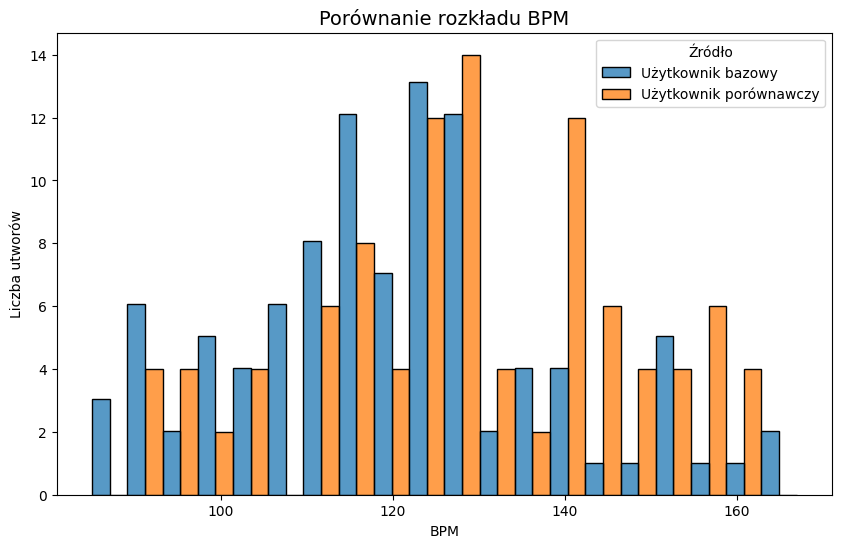

In [ ]:
user_bpm = pd.to_numeric(df["bpm"], errors="coerce").dropna()
global_bpm = pd.to_numeric(df_top["bpm"], errors="coerce").dropna()
bpm_df = pd.DataFrame({
    "BPM": list(user_bpm) + list(global_bpm),
    "Źródło": ["Użytkownik bazowy"] * len(user_bpm) + ["Użytkownik porównawczy"] * len(global_bpm)
})


# Utwórz figurę i oś ręcznie, by mieć pełną kontrolę
fig, ax = plt.subplots(figsize=(10, 6))

# Przezroczystość tła wykresu i figury
ax.set_facecolor((1, 1, 1, 0.3))  # przezroczystość osi
fig.patch.set_alpha(0.3)         # przezroczystość całej figury

# Rysowanie wykresu
sns.histplot(data=bpm_df, x="BPM", hue="Źródło", stat='percent', common_norm=False, bins=20, multiple="dodge", ax=ax)

# Tytuł (opcjonalnie)
ax.set_title("Porównanie rozkładu BPM", fontsize=14, y=1.0)
ax.set_ylabel("Procent utworów")
ax.set_xlabel("BPM")
# Zapis z przezroczystym tłem (opcjonalnie)

fig.savefig("fig15.png", transparent=True)


C:\Users\marci\AppData\Local\Temp\ipykernel_20564\3134308757.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Źródło")


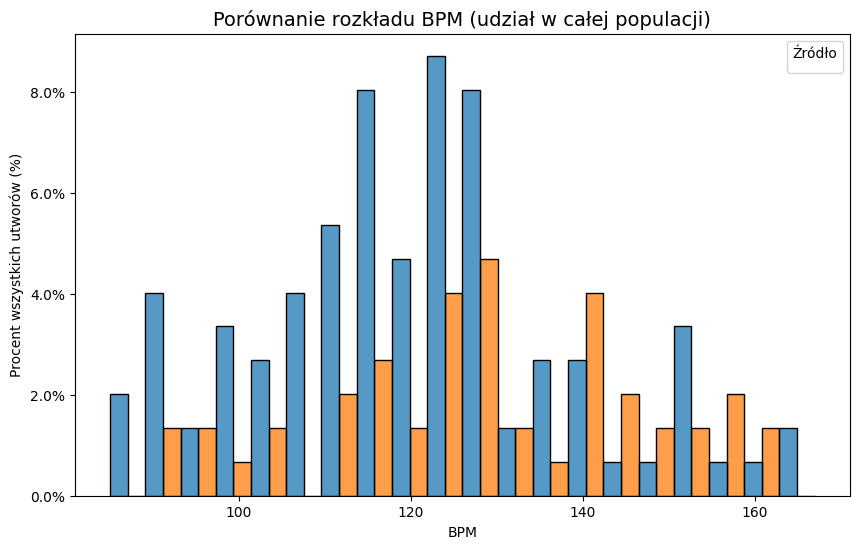

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

user_bpm = pd.to_numeric(df["bpm"], errors="coerce").dropna()
global_bpm = pd.to_numeric(df_top["bpm"], errors="coerce").dropna()

bpm_df = pd.DataFrame({
    "BPM": list(user_bpm) + list(global_bpm),
    "Źródło": ["Użytkownik bazowy"] * len(user_bpm) + ["Użytkownik porównawczy"] * len(global_bpm)
})

# Waga każdej próbki tak, aby suma wag = 100 (procent całej populacji)
bpm_df['weight'] = 100.0 / len(bpm_df)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor((1, 1, 1, 0.3))
fig.patch.set_alpha(0.3)

sns.histplot(
    data=bpm_df,
    x="BPM",
    hue="Źródło",
    bins=20,
    weights="weight",        # używamy wag
    stat="percent",              # sumujemy wagi -> otrzymamy procenty
    multiple="dodge",
    ax=ax
)

# Formatowanie osi Y jako procenty
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}%"))

ax.set_title("Porównanie rozkładu BPM (udział w całej populacji)", fontsize=14, y=1.0)
ax.set_xlabel("BPM")
ax.set_ylabel("Procent wszystkich utworów (%)")
ax.legend(title="Źródło")

fig.savefig("fig15.png", transparent=True)
plt.show()


In [11]:
all_tags = []
for tags_list in df['Tags']:
    if isinstance(tags_list, str) and pd.notna(tags_list):
        tags = tags_list.split(',')
        all_tags.extend([tag.strip(" []'\"") for tag in tags])

In [13]:
all_tags = []
for tags_list in df['Tags']:
    if isinstance(tags_list, str) and pd.notna(tags_list):
        tags = tags_list.split(',')
        all_tags.extend([tag.strip(" []'\"") for tag in tags])

tag_counts = pd.Series(all_tags).value_counts(normalize=True) * 100

# Najpopularniejsze tagi
top_tags = tag_counts.head(7)
other_tags = tag_counts[7:]

if not other_tags.empty:
    top_tags["Inne"] = other_tags.sum()

tag_df = top_tags.reset_index()
tag_df.columns = ['Tag', 'Percentage']

# Lista 3 najpopularniejszych tagów
top_3 = tag_counts.head(3).index.tolist()

In [11]:
from wordcloud import WordCloud #potrzebne do wizualizacji chmury słow
import ast

def generate_wordcloud(df):
    all_genres = []
    for item in df["Genres"].dropna():
        try:
            genres = ast.literal_eval(item)
            for genre in genres:
                parts = genre.lower().split()
                all_genres.extend(parts)
        except Exception:
            continue
    text = " ".join(all_genres)
    wc = WordCloud(width=500, height=300, background_color="white").generate(text)
    return wc

# Obróbka wszystkich plików z danego folderu i update loklanej bazy

In [ ]:
# Library import

from dotenv import load_dotenv
import os
from pathlib import Path

load_dotenv("log_data.env")

# Plugin import

from Plugins.DataProcess import WrappedListProcess

# Wprowadzenie danych wejściowych

analyser_path = Path(os.getcwd()).resolve()
data_dir = analyser_path / "NewData" 

file_list = os.listdir(data_dir)

output_path = analyser_path / "DataOutput" 


for file in file_list:
    wrapped_list = WrappedListProcess()
    wrapped_list.process_list(
        file_name=file,
        data_path=analyser_path
        )
